# Science, Technology & Innovation Performance: A Cross-Country Analysis Using OECD Data
**Author:** [VISHAL POTE] | **Data retrieved:** 4 October 2026 | **Source:** OECD Main Science and Technology Indicators (MSTI) via the public SDMX API (no API key needed)

**Research questions**
1. How does R&D intensity (GERD as % of GDP) vary across countries?
2. How has it changed since 2010?
3. Is R&D intensity associated with patent activity and researcher numbers?

Countries: Australia, Canada, China, France, Germany, Japan, Korea, South Africa, United Kingdom, United States. India is not in MSTI, so it is left for future work.

In [6]:
!pip install -q pandas numpy matplotlib seaborn requests

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from io import StringIO

os.makedirs("figures", exist_ok=True)
print("Environment ready")

Environment ready


## 1. Data retrieval
R&D expenditure (GERD, % of GDP), annual, 2010 onwards. Dataset `OECD.STI.STP,DSD_MSTI@DF_MSTI,1.3`.
Run this cell once only: the OECD rate-limits repeated requests.

In [8]:
url = (
    "https://sdmx.oecd.org/public/rest/data/"
    "OECD.STI.STP,DSD_MSTI@DF_MSTI,1.3/"
    "DEU+GBR+USA+CHN+KOR+JPN+FRA+CAN+AUS+ZAF.A.G.PT_B1GQ.."
    "?startPeriod=2010"
    "&dimensionAtObservation=AllDimensions"
    "&format=csvfilewithlabels"
)
response = requests.get(url)
print("Status:", response.status_code)
rd_full = pd.read_csv(StringIO(response.text), low_memory=False)
print(rd_full.shape)

Status: 200
(142, 36)


## 2. Data quality: observation flags and time series breaks
The OECD flags values as estimated, provisional or a **time series break** (the measurement method changed, so values before and after are not strictly comparable). Example: the UK.

In [9]:
print([c for c in rd_full.columns if "status" in c.lower()])
rd_full[rd_full["Reference area"] == "United Kingdom"][
    ["TIME_PERIOD", "OBS_VALUE", "Observation status"]
].sort_values("TIME_PERIOD")

['OBS_STATUS', 'Observation status', 'OBS_STATUS_2', 'Observation status 2', 'OBS_STATUS_3', 'Observation status 3', 'AUX_OBS_STATUS', 'Aux observation status', 'CONF_STATUS', 'Confidentiality status']


,TIME_PERIOD,OBS_VALUE,Observation status
75,2010,1.631474,Estimated value
134,2011,1.639557,NaN
74,2012,1.568559,Estimated value
133,2013,1.613971,NaN
139,2014,2.249718,Time series break
62,2015,2.262009,Estimated value
3,2016,2.305342,Estimated value
2,2017,2.309668,Estimated value
138,2018,2.684861,Time series break
99,2019,2.648128,Provisional value


In [10]:
rd = rd_full[["Reference area", "TIME_PERIOD", "OBS_VALUE",
              "Observation status", "Observation status 2", "Observation status 3"]].copy()
rd.columns = ["country", "year", "rd_pct_gdp", "status", "status2", "status3"]
rd["is_break"] = rd[["status", "status2", "status3"]].eq("Time series break").any(axis=1)
rd = rd.sort_values(["country", "year"]).reset_index(drop=True)

print(rd.duplicated(["country", "year"]).sum(), "duplicate rows")
rd.groupby("country")["year"].agg(["min", "max", "count"])

0 duplicate rows


,min,max,count
country,,,
Australia,2010,2023,8
Canada,2010,2025,16
China (People’s Republic of),2010,2024,15
France,2010,2024,15
Germany,2010,2024,15
Japan,2010,2024,15
Korea,2010,2024,15
South Africa,2010,2023,14
United Kingdom,2010,2023,14


## 3. R&D intensity trends
Only countries with **no flagged break** are ranked by change since 2010. All countries appear in the chart, with breaks marked by x.
Note: Australia reports every other year.

Clean countries: ['Australia', 'China (People’s Republic of)', 'Germany', 'Korea', 'South Africa']
country
Australia                       0
Canada                          2
China (People’s Republic of)    0
France                          2
Germany                         0
Japan                           2
Korea                           0
South Africa                    0
United Kingdom                  2
United States                   4
                              first_year  last_year  first  last  change_pp
country                                                                    
Korea                             2010.0     2024.0   3.18  5.13       1.95
China (People’s Republic of)      2010.0     2024.0   1.68  2.69       1.01
Germany                           2010.0     2024.0   2.68  3.13       0.45
South Africa                      2010.0     2023.0   0.66  0.62      -0.05
Australia                         2010.0     2023.0   2.17  1.68      -0.49


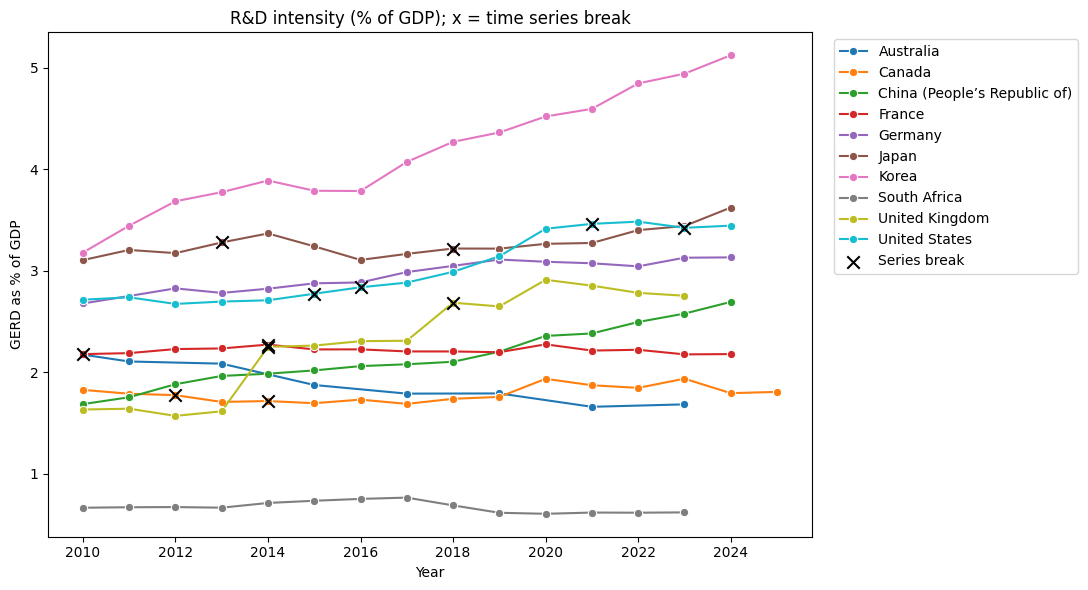

In [11]:
break_counts = rd.groupby("country")["is_break"].sum()
clean = break_counts[break_counts == 0].index.tolist()
print("Clean countries:", clean)
print(break_counts.to_string())

def change_table(d):
    d = d.dropna(subset=["rd_pct_gdp"]).sort_values("year")
    f, l = d.iloc[0], d.iloc[-1]
    return pd.Series({"first_year": f["year"], "last_year": l["year"],
                      "first": f["rd_pct_gdp"], "last": l["rd_pct_gdp"],
                      "change_pp": l["rd_pct_gdp"] - f["rd_pct_gdp"]})

summary = (rd[rd.country.isin(clean)]
           .groupby("country")[["year", "rd_pct_gdp"]].apply(change_table).round(2))
print(summary.sort_values("change_pp", ascending=False))

plt.figure(figsize=(11, 6))
sns.lineplot(data=rd, x="year", y="rd_pct_gdp", hue="country", marker="o")
b = rd[rd.is_break]
plt.scatter(b.year, b.rd_pct_gdp, marker="x", color="black", s=80, zorder=5, label="Series break")
plt.title("R&D intensity (% of GDP); x = time series break")
plt.xlabel("Year"); plt.ylabel("GERD as % of GDP")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("figures/rd_intensity_trend.png", dpi=200)
plt.show()

rd.to_csv("rd_clean.csv", index=False)

## 4. Second indicators: patents and researchers
Download all MSTI measures for the same countries, then check units before using any measure.

In [12]:
url_all = (
    "https://sdmx.oecd.org/public/rest/data/"
    "OECD.STI.STP,DSD_MSTI@DF_MSTI,1.3/"
    "DEU+GBR+USA+CHN+KOR+JPN+FRA+CAN+AUS+ZAF.A...."
    "?startPeriod=2010"
    "&dimensionAtObservation=AllDimensions"
    "&format=csvfilewithlabels"
)
r2 = requests.get(url_all)
print("Status:", r2.status_code)
allm = pd.read_csv(StringIO(r2.text), low_memory=False)
print(allm.shape)

Status: 200
(18575, 36)


In [13]:
for m in ["P_PCT", "P_TRIAD", "T_RS", "TOT_POP", "TOT_EMP"]:
    sub = allm[allm["MEASURE"] == m]
    print("\n==", m, "| rows:", len(sub))
    print(sub.groupby(["UNIT_MEASURE", "Unit of measure"]).size().to_string())
    print("UNIT_MULT:", sub["UNIT_MULT"].unique())
    print("Years:", sub["TIME_PERIOD"].min(), "-", sub["TIME_PERIOD"].max())
    print("Countries with data:", sub["Reference area"].nunique())


== P_PCT | rows: 140
UNIT_MEASURE  Unit of measure
PATN          Patents            140
UNIT_MULT: [0]
Years: 2010 - 2023
Countries with data: 10

== P_TRIAD | rows: 280
UNIT_MEASURE  Unit of measure                            
PATN          Patents                                        140
PT_PATN_FM_T  Percentage of world triadic patent families    140
UNIT_MULT: [0]
Years: 2010 - 2023
Countries with data: 10

== T_RS | rows: 451
UNIT_MEASURE  Unit of measure          
10P3EMP       Per 1 000 employment         125
FTE           Full time equivalent unit    250
PS            Persons                       76
UNIT_MULT: [0]
Years: 2010 - 2024
Countries with data: 9

== TOT_POP | rows: 155
UNIT_MEASURE  Unit of measure
PS            Persons            155
UNIT_MULT: [3]
Years: 2010 - 2025
Countries with data: 10

== TOT_EMP | rows: 153
UNIT_MEASURE  Unit of measure
PS            Persons            153
UNIT_MULT: [3]
Years: 2010 - 2025
Countries with data: 10


Choices based on the unit check:
- **Patents:** `P_PCT` (PCT applications, count), scaled to patents per million people.
- **Researchers:** only unit `10P3EMP` (per 1,000 employed); FTE and persons are different units. Australia has no data.
- **Population:** `UNIT_MULT = 3`, so values are in thousands and are converted to persons.

## 5. Association analysis
Country averages for 2015-2022 reduce single-year noise and Australia's gaps. Pearson and Spearman correlations, with and without Korea.
A regression is deliberately not run: with n = 10 countries it would not be meaningful.

P_PCT duplicate country-years: 0
TOT_POP duplicate country-years: 0
T_RS duplicate country-years: 0

Countries with no researcher data: ['Australia']

Country averages, 2015-2022:
                              rd_pct_gdp  patents_per_million  researchers_per_1000
country                                                                            
Korea                               4.28               348.69                 15.50
Japan                               3.24               368.65                 10.12
United States                       3.12               167.87                  9.74
Germany                             3.01               223.82                  9.77
United Kingdom                      2.59                96.06                  9.18
France                              2.22               115.57                 10.84
China (People’s Republic of)        2.21                39.41                  2.72
Australia                           1.78                73.50   

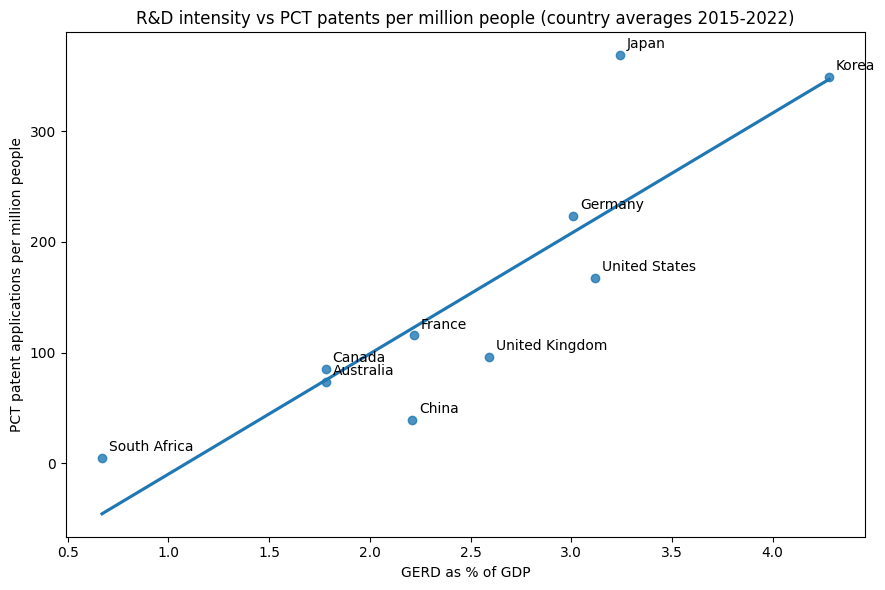

In [14]:
def get(m, unit=None):
    s = allm[allm["MEASURE"] == m].copy()
    if unit:
        s = s[s["UNIT_MEASURE"] == unit]
    s["value"] = s["OBS_VALUE"] * (10 ** s["UNIT_MULT"])   # converts "thousands"
    s = s.rename(columns={"Reference area": "country", "TIME_PERIOD": "year"})
    s = s[["country", "year", "value"]]
    print(m, "duplicate country-years:", s.duplicated(["country", "year"]).sum())
    return s.groupby(["country", "year"], as_index=False)["value"].mean()

pat = get("P_PCT", "PATN").rename(columns={"value": "patents"})
pop = get("TOT_POP", "PS").rename(columns={"value": "pop"})
rs  = get("T_RS", "10P3EMP").rename(columns={"value": "researchers_per_1000"})

pp = pat.merge(pop, on=["country", "year"])
pp["patents_per_million"] = pp["patents"] / pp["pop"] * 1e6

Y0, Y1 = 2015, 2022
win = lambda d: d[(d.year >= Y0) & (d.year <= Y1)]

t = win(rd).groupby("country")["rd_pct_gdp"].mean().to_frame("rd_pct_gdp")
t = t.join(win(pp).groupby("country")["patents_per_million"].mean())
t = t.join(win(rs).groupby("country")["researchers_per_1000"].mean())
t = t.round(2)
print("\nCountries with no researcher data:", t[t.researchers_per_1000.isna()].index.tolist())
print(f"\nCountry averages, {Y0}-{Y1}:")
print(t.sort_values("rd_pct_gdp", ascending=False).to_string())

def corr_report(df, x, y, label):
    d = df[[x, y]].dropna()
    print(f"{label}: n={len(d)}, Pearson={d[x].corr(d[y]):.2f}, Spearman={d[x].corr(d[y], method='spearman'):.2f}")

print()
corr_report(t, "rd_pct_gdp", "patents_per_million", "R&D vs patents/million (all)")
corr_report(t.drop("Korea"), "rd_pct_gdp", "patents_per_million", "R&D vs patents/million (no Korea)")
corr_report(t, "rd_pct_gdp", "researchers_per_1000", "R&D vs researchers/1000 (all)")

d = t.dropna(subset=["patents_per_million"])
plt.figure(figsize=(9, 6))
sns.regplot(data=d, x="rd_pct_gdp", y="patents_per_million", ci=None)
for c, r in d.iterrows():
    plt.annotate(c.replace(" (People\u2019s Republic of)", ""), (r.rd_pct_gdp, r.patents_per_million),
                 xytext=(5, 5), textcoords="offset points")
plt.title(f"R&D intensity vs PCT patents per million people (country averages {Y0}-{Y1})")
plt.xlabel("GERD as % of GDP")
plt.ylabel("PCT patent applications per million people")
plt.tight_layout()
plt.savefig("figures/rd_vs_patents.png", dpi=200)
plt.show()

t.to_csv("country_summary.csv")

## 6. Key findings
- Korea has the highest R&D intensity (5.1% of GDP in 2024) and the largest rise since 2010 (+1.95 percentage points). Among the five countries with break-free series, China rose +1.01 and Germany +0.45; Australia fell -0.49 and South Africa was flat.
- R&D intensity is strongly associated with PCT patents per million people (Pearson 0.87, Spearman 0.92, n=10; Pearson 0.80 without Korea) and with researchers per 1,000 employed (Pearson 0.80, n=9).
- China files fewer patents per capita than its R&D intensity suggests; Japan files more. Possible reasons (population denominator, use of domestic patent offices) are hypotheses, not findings.

## 7. Limitations
- Only 5 of 10 countries have series with no flagged time series break, so the change ranking covers those five only. The UK has two breaks (2014, 2018) and its apparent rise is largely a measurement artefact.
- Latest years are provisional or estimated; countries end in different years; Australia reports every other year and has no researcher data.
- n = 10: correlations are fragile and descriptive. They show association, not causation. Economic size, industry structure and patenting practices are uncontrolled confounders.
- PCT counts capture international filings only; per-capita scaling penalises very populous countries.
- Averages for 2015-2022 include some break-flagged years.

## 8. Future work
Add India from the World Bank, expand the country set, and use panel regression with controls.